In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from src.models.utils import *

In [2]:
_='''
read data from semi_processed

select is_good_peak == 3

see interval_id

devid interval to n batch (each k interval) each batch [i1,i2)

write class model that get intreval of interval id [i1,i2) and run model over interval [i1,i2)
model get interval [i3,i4) and test model over it

for each batch train Model
and test it over interval after and before

if error < threshould then merge to batch and train new model and compute error for before and after batch

do this work until no error least than thresould
'''

# S1

In [3]:

# Placeholder for your actual model class
class Model:
    def __init__(self, interval, data):
        self.interval = interval
        self.data = data
        self.model = None
        self.n_mimo = 1

    def train(self):
        # TODO: Implement model training on self.data
        
        train_data = get_in(self.data,self.interval)
        train_data = train_data[["generation"]+["temperature"]]#,"humidity", "dew", "surface_pressure"]]
        X = train_data.drop(columns=["generation"])
        y = train_data["generation"]
        
        model = LinearRegression()
        model.fit(X,y)
        self.model = model
        
        #print(f"Training model on interval [{self.i_start}, {self.i_end}) with {len(self.data)} rows")
        

    def test(self, interval):
        y_pred,y = self.pred(interval)
        rmse_error_test = compute_relative_rmse(y_pred, y)
        return rmse_error_test
    
    def pred(self, interval):
        if interval == None : interval = self.interval
        test_data = get_in(self.data,interval)
        test_data = test_data[["generation"]+["temperature"]]#,"humidity", "dew", "surface_pressure"]]
        X = test_data.drop(columns=["generation"])
        y = test_data["generation"]
    
        y_pred = self.model.predict(X)
        return y_pred,y


def split_intervals(intervals, batch_size):
    """Split sorted unique interval IDs into batches of size batch_size"""
    batches = []
    for i in range(0, len(intervals), batch_size):
        batches.append((i,i+batch_size))
    batches[-1] = (batches[-1][0],len(intervals))
    return batches
    
def split_intervals_by_month(df,interval_ids):
    df1 = df.copy()
    df1['datetime'] = pd.to_datetime(df1['datetime'])
    df1['year_month'] = pd.to_datetime(df1['datetime'].dt.to_period('M').astype(str))
    
    interval_id_year_month = [df1[df1['interval_id'] == interval].iloc[0]['year_month'] for interval in interval_ids]
    interval_id_year_month = np.array(interval_id_year_month)
    mask = np.diff(interval_id_year_month) != pd.Timedelta(0,unit='h')
    
    index_id = np.where(mask)[0]+1
    start_indices = [0]+list(index_id)
    end_indices = list(index_id)+[len(interval_ids)]
    batches = list(zip(start_indices,end_indices))
    return batches

def get_in(df,i):
    (i1,i2) = i
    mask = (i1 <= df['interval_id']) & (df['interval_id'] < i2)
    return df[mask]

In [4]:
def start(df,name,code):
    # Select rows where is_good_peak == 3
    filtered_df = df[(df["name"] == name)&(df["code"] == code)&(df['is_good_peak'] >= 3)]
    filtered_df = filtered_df[["name","code","datetime","generation",'interval_id',"temperature", "humidity", "dew", "surface_pressure"]]
    # Unique sorted interval IDs
    unique_intervals = sorted(filtered_df['interval_id'].unique())

    batch_size = 10  # For example, number of intervals per batch
    # batches = split_intervals(unique_intervals, batch_size)
    batches = split_intervals_by_month(filtered_df[['interval_id','datetime']],unique_intervals)
    batch_models = []
    errors = [[None,None] for i in range(len(batches))]

    for idx, batch_intervals in enumerate(batches):
        
        # Train model on current batch
        batch_model = Model(batch_intervals, filtered_df)
        batch_model.train()

        # Test model on before and after intervals
        error_before = None
        error_after = None

        if idx > 0:
            # Test on previous batch interval
            prev_intervals = batches[idx-1]
            error_before = batch_model.test(prev_intervals)
            errors[idx][0] = error_before

        if idx < len(batches) - 1:
            # Test on next batch interval
            next_intervals = batches[idx+1]
            error_after = batch_model.test(next_intervals)
            errors[idx][1] = error_after

        #print(f"Batch {idx}: error_before={error_before}, error_after={error_after}")

        batch_models.append(batch_model)
        
        clean = lambda x : x if x != None else 100
        errors = [[clean(e[0]),clean(e[1])] for e in errors]
    return batch_models,batches,errors,filtered_df

# Repeat merging & retraining logic until no error less than threshold
# You can wrap above in a loop and add conditions accordingly
# batch_models,batches,errors,filtered_df = start(df)

In [5]:
def merge_batches(batches, batch_models, df, errors, threshold):
    """
    Merge adjacent batches in the 'batches' list when the error between their models is below 'threshold'.
    
    Parameters:
    batches (list of list): Each inner list contains interval_ids representing one batch.
    batch_models (list): List of trained Model instances corresponding to batches.
    df (pd.DataFrame): The dataframe containing the data with 'interval_id' column.
    threshold (float): Error threshold to decide whether to merge batches.
    
    Returns:
    batches (list of list): Updated list of batches after merging.
    batch_models (list): Updated list of models after retraining on merged batches.
    merged (bool): True if any merge was performed, otherwise False.
    """
    
    i = (np.array([error[0] for error in errors])[1:]+np.array([error[1] for error in errors])[:-1]).argmin()
    #i = np.array(errors[i][1]+errors[i+1][0] for i in range(len(errors)-1)).argmin()
    
    error_min = errors[i][1]
    if error_min < threshold:
        # Merge batches i and i+1
        if i < len(batches)-1:
            new_batch = (batches[i][0],batches[i+1][1])
        else:
            new_batch = (batches[i][0],batches[i+1][1]) 

        # Train a new model on the merged data
        new_model = Model(new_batch, df)
        new_model.train()
        # Update batches and models lists by replacing merged batches with the new one
        batches[i] = new_batch
        batch_models[i] = new_model
        del batches[i+1]
        del batch_models[i+1]
        
        e2 = batch_models[i].test(batches[i+1]) if i < len(batches)-1 else 100
        e1 = batch_models[i].test(batches[i-1]) if i > 0 else 100
        errors[i] = [e1, e2]
        del errors[i+1]
        
        if i < len(errors)-1:
            errors[i+1][0] = batch_models[i+1].test(batches[i])     
        if i > 0:
            errors[i-1][1] = batch_models[i-1].test(batches[i])
        
        '''
        errors[i] = test new model on pre and next batch
        del errors[i+1]
        errors[i-1][1] = test model[i-1] on new batch
        errors[i+1][0] = test model[i+1] on new batch
        '''
        return True,i,error_min
    return False,None,error_min


In [6]:
import pandas as pd
import plotly.express as px

# Function to assign batch label to each row based on interval_id
def assign_batch(interval_id,batches):
    for i, (start, end) in enumerate(batches):
        if start <= interval_id < end:
            return f'batch_{i+1}'
    return 'out_of_batch'

def show(filtered_df,batches,num=None,save=False,parm=None):
    if num != None : num = [f"batch_{i}" for i in num]
    df_plot = filtered_df.copy()

    assign_batch_m = lambda interval_id : assign_batch(interval_id,batches)
    df_plot['batch'] = df_plot['interval_id'].apply(assign_batch_m)
    #pred_pred(batch_models,df_plot)
    
    if num != None : df_plot = df_plot[df_plot['batch'].isin(num)]
    df_plot
    # Plot with plotly express, color by batch so each batch gets a distinct color
    fig = px.scatter(df_plot, x="datetime", y='generation', color='batch',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation', 'datetime': 'Time'},
                hover_data=['datetime', 'generation', 'temperature','interval_id'])

    if save:
        fig.write_html(f"{project_root}/src/visualization/unit_figs/outer_plant/{parm['name']}-{parm['code']}.html")
    else:
        fig.show()
    fig = px.scatter(df_plot, x="temperature", y='generation', color='batch',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation', 'datetime': 'Time'},
                hover_data=['datetime', 'generation', 'temperature','interval_id'])
    if save:
        fig.write_html(f"{project_root}/src/visualization/unit_figs/outer_plant/{parm['name']}-{parm['code']}_s.html")
    else:
        fig.show()
    
def pred_pred(batch_models,df_plot):
    df_plot["prediction"] = None
    for i,model in enumerate(batch_models):
        y1,_ = model.pred(interval=None)
        data = df_plot[df_plot['batch'] == f"batch_{i+1}"]
        print(i,len(y1),len(data),model.interval)
        df_plot.loc[data.index,"prediction"] = y1

In [7]:
def d_model(m1,m2):
    c1 = m1.model.coef_
    c2 = m2.model.coef_
    d1 = m1.model.intercept_
    d2 = m2.model.intercept_
    return sum((c1 - c2)**2) + ((d1-d2)/(d1+d2))**2,d1,d2,((d1-d2)*2/(d1+d2))

In [8]:
pd.set_option('future.no_silent_downcasting', True)
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')


In [9]:
df_nc = df[['name','code']].drop_duplicates()
for _,row in df_nc.iterrows():
    name = row["name"]
    code = row["code"]
    if code.startswith("S"):
        continue
    batch_models,batches,errors,filtered_df = start(df,name,code)
    k = 1
    threshold = 10000
    is_merged = True
    while len(batch_models) > k and is_merged:
        is_merged,i,error_min = merge_batches(batches, batch_models, filtered_df,errors, threshold)
    if len(batch_models) != 1:
        print(name,code,len(batch_models),error_min) 
    show(filtered_df,batches,save=True,parm={"name":name,"code":code})
    #print(len(errors),len(batches),i)

In [10]:
name = "پرند"
code = "G11"
batch_models,batches,errors,filtered_df = start(df,name,code)
k = 2
threshold = 100
is_merged = True
while len(batch_models) > k and is_merged:
    is_merged,i,error_min = merge_batches(batches, batch_models, filtered_df,errors, threshold)
print(name,code,len(batch_models),error_min) 
show(filtered_df,batches)

پرند G11 2 32.85841799246945


In [11]:
errors

[[100, 7.782869664838531], [10.556561024009719, 100]]

In [12]:
_='''
is_merged,i,error_min = merge_batches(batches, batch_models, filtered_df,errors, threshold=100)
print(len(errors))
print(error_min)
print(errors)
show(filtered_df,batches)'''

# S2

In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


def assign_batch(interval_id,batches):
    for i, (start, end) in enumerate(batches):
        if start <= interval_id < end:
            return i
    return -1

def label(filtered_df,batches):
    df_plot = filtered_df.copy()
    assign_batch_m = lambda interval_id : assign_batch(interval_id,batches)
    df_plot['batch'] = df_plot['interval_id'].apply(assign_batch_m)
    return df_plot.drop(columns=["batch"]),df_plot["batch"]
    
def check(X,y):

    # تعریف مدل SVM با کرنل خطی (Linear Kernel)
    model = SVC(kernel='linear')

    # آموزش مدل
    model.fit(X, y)

    # پیش‌بینی روی داده تست
    y_pred = model.predict(X)
    #print("Accuracy:", accuracy_score(y, y_pred))
    return y_pred
    # دقت مدل

In [14]:
_='''
X,y = label(filtered_df,batches)
X = X[["generation"]+["temperature","humidity", "dew", "surface_pressure"]]
y_pred = check(X,y)
print(classification_report(y, y_pred))
'''

In [15]:
pd.set_option('future.no_silent_downcasting', True)
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')


In [16]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
def select_month(df,m1,m2,y1,y2):
    df["datetime"] = pd.to_datetime(df["datetime"])
    year_s  = df["datetime"].dt.year
    month_s = df["datetime"].dt.month
    mask1 = (year_s == y1) & (month_s == m1)
    mask2 = (year_s == y2) & (month_s == m2)
    df_month = df[mask1|mask2]
    df_month["label_month"] = 1
    mm1 = mask1[mask1]
    mm2 = mask2[mask2]
    df_month.loc[mm1.index,"label_month"] = 1
    df_month.loc[mm2.index,"label_month"] = 2
    return df_month,len(mm1),len(mm2)

name = "عسلویه"  # "شهدای پیروز - بهبهان" #"جنوب اصفهان - چهلستون"
code = "G11" # "G16"
df_m = df[(df["name"] == name)&(df["code"] == code)&(df['is_good_peak'] >= 3)]
array = []
time = []

df_m['datetime'] = pd.to_datetime(df_m['datetime'])
start = df_m['datetime'].min().replace(day=1)
end = df_m['datetime'].max().replace(day=1) + pd.DateOffset(months=1)
full_range = pd.date_range(start=start, end=end, freq='MS')
df_full_range = pd.DataFrame({'year_month': full_range})['year_month']
df_new = pd.DataFrame({'year': df_full_range.dt.year, 'month': df_full_range.dt.month})

for _,row in df_new.drop_duplicates().iterrows():
    month = row['month']
    year = row['year']
    year1 = year
    year2 = year + 1
    
    datetime = pd.to_datetime({'year': [year], 'month': [month], 'day': [1]})
    df_month,n1,n2 = select_month(df_m,month,month,year1,year2)
    print(n1,n2)
    if n1 != 0 and n2 != 0:    
        X = df_month[["generation"]+["temperature"]]
        y = df_month["label_month"]
        y_pred = check(X,y)
        d = classification_report(y, y_pred,output_dict=True,zero_division=0)
        array.append(d['accuracy'])
        time.append(datetime[0])
    else:
        array.append(None)
        time.append(datetime[0])
        
array = np.array(array)[:-12]
time = np.array(time)[:-12]

36 28
61 58
147 64
81 20
105 58
44 16
0 64
0 88
40 76
96 108
28 56
0 0
28 90
58 265
64 244
20 76
58 221
16 44
64 0
88 36
76 28
108 40
56 28
0 0
90 74
265 261
244 248
76 291
221 208
44 68
0 40
36 48
28 48
40 40
28 0
0 0
74 0
261 0
248 0
291 0
208 0
68 0
40 0
48 0
48 0
40 0
0 0


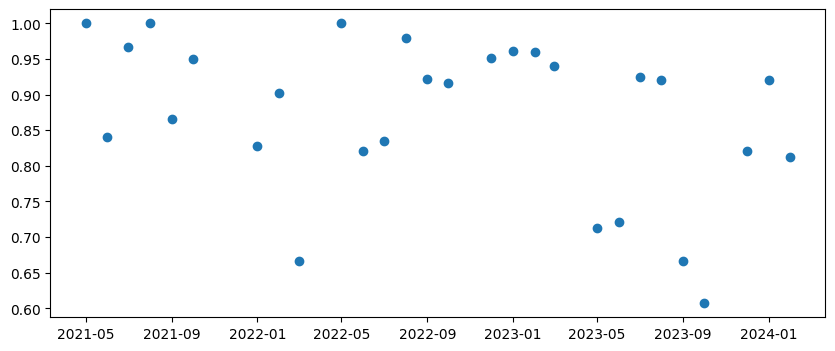

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(time,array)

In [18]:
def my_func(x,th):
    if x == None:
        return None
    if x > th:
        return 1
    return 0
th = 0.94
result = np.array([my_func(x,th) for x in array])
result

array([1, 0, 1, 1, 0, 1, None, None, 0, 0, 0, None, 1, 0, 0, 1, 0, 0,
       None, 1, 1, 1, 1, None, 0, 0, 0, 0, 0, 0, None, 0, 0, 0, None],
      dtype=object)

In [19]:
min(time)

Timestamp('2021-05-01 00:00:00')

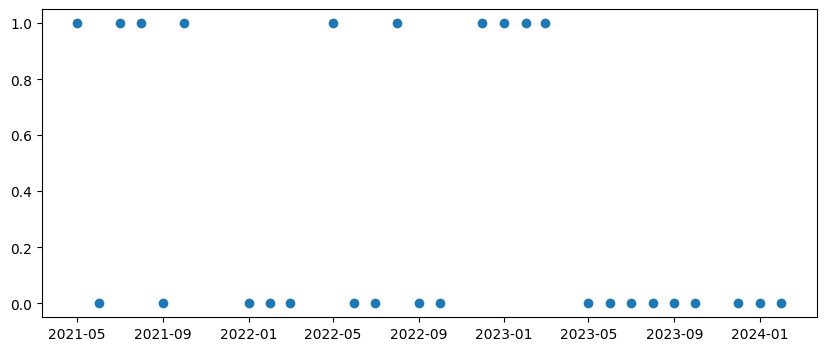

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(time,result)

In [21]:
def get_el(a,i,f):
    if i < 0 or i >= len(a):
        return 0,0
    if a[i] == None:
        if f : return 0,0
        else : return 0,0
    return a[i],1
def normal_filter(array,index,k):
    k = min(index+1,k)
    k = min(len(array)-index,k)
    m = 0
    n = 0
    for i in range(index-k,index+k+1):
        mm,nn = get_el(array,i,i==index)
        if i==index:
            if mm == 1:
                nn == 4
                mm == 4
        m += mm
        n += nn
        
    if n == 0:
        return None
    
    f = m/n
    f = 1 if f >= 0.5 else 0
    return f

In [22]:
def f(result):
    return np.array([normal_filter(result,i,k=3) for i in range(len(result))])
def f_n(result,n):
    for i in range(n):
        result = f(result)
    return result

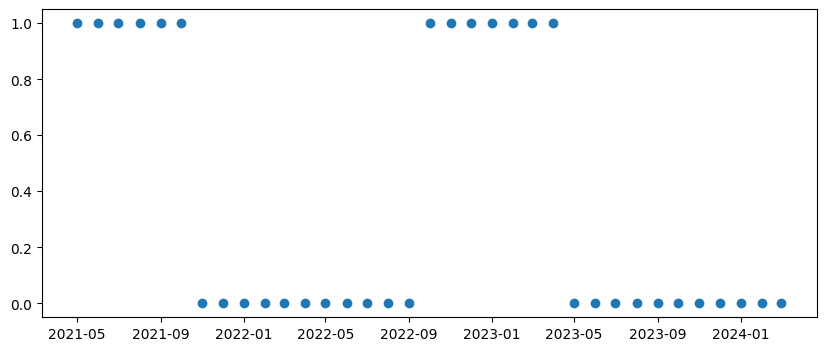

In [23]:
r = f_n(result,3)
#r = f(result)
#r = f(r)
#r = f(r) # بازه اولیه را کامل ببین! حتی اگر بالای 12 ماه بود # TODO
#r = f(r)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(time,r)

In [24]:
def find_intervals(arr, k):
    start = None
    count = 0
    intervals = []
    
    for i, num in enumerate(arr):
        if num == 1:
            if start is None:
                start = i  # شروع بازه جدید
            count += 1
        elif num == 0:
            if count >= k:
                intervals.append((start, i - 1))
            start = None
            count = 0
    
    # بررسی بازه پایانی
    if count >= k:
        intervals.append((start, len(arr) - 1))
    
    return intervals

In [25]:
def find_time_intervals(intervals,dates):
        
    end = len(dates)-1
    last_time = max(dates)
    k = []
    y1 = np.timedelta64(1,'Y').astype('timedelta64[ns]')#pd.DateOffset(years=1)#np.timedelta64(1,'M').astype('timedelta64[ns]')
    for i1,i2 in intervals:
        if i2 != end:
            print("RR",i2,end,dates[i2])
            k.append(dates[i2])
        else :
            print("GG",dates[i1]+y1,last_time,dates[i2])
            k.append(min(dates[i1]+y1,last_time))
    return k

In [26]:
intervals = find_intervals(r, k=7)
dates_interval = find_time_intervals(intervals,time)

RR 23 34 2023-04-01 00:00:00


In [27]:
dates_interval,intervals

([Timestamp('2023-04-01 00:00:00')], [(17, 23)])

In [28]:
from src.models.data_selection.data_selector import Data_selector
def label_points(df, ds, power_plants, dates_by_name_code, label):
    all_indices = []
    for _, row in power_plants.iterrows():
        name, code = row['name'], row['code']
        df_name_code = ds.filter_name_code(name, code)
        dates = dates_by_name_code[(name, code)]

        interval_ds = Data_selector(df_name_code)
        for date1, date2 in dates:
            flag_array = interval_ds.filter_time(date1, date2, get_mask=True)
            indices = flag_array.index[flag_array]
            all_indices.extend(indices)
    df.loc[all_indices, "is_good_peak"] = label

In [29]:
def label_points_my(df, ds, power_plants, dates_by_name_code):
    df['color'] = 0
    for _, row in power_plants.iterrows():
        name, code = row['name'], row['code']
        df_name_code = ds.filter_name_code(name, code)
        dates = dates_by_name_code[(name, code)]

        interval_ds = Data_selector(df_name_code)
        k = 0
        print(dates)
        for date1, date2 in dates:
            all_indices = [] 
            flag_array = interval_ds.filter_time(date1, date2, get_mask=True,close_open=True)
            indices = flag_array.index[flag_array]
            all_indices.extend(indices)
            df.loc[all_indices, "color"] = k
            k += 1

In [32]:
ds = Data_selector(df_m)
power_plants = df_m[['name', 'code']].drop_duplicates()
time_e = [min(df_m["datetime"])] + dates_interval + [max(df_m["datetime"]) + pd.DateOffset(months=1)]
time_intervals = [(time_e[i],time_e[i+1]) for i in range(len(time_e)-1)]
dates_by_name_code = {(name,code):time_intervals}
df_m1 = df_m.copy()
label_points_my(df_m1, ds, power_plants, dates_by_name_code)

[(Timestamp('2021-05-24 09:00:00'), Timestamp('2023-04-01 00:00:00')), (Timestamp('2023-04-01 00:00:00'), Timestamp('2025-03-21 21:00:00'))]


In [33]:
import plotly.express as px

fig = px.scatter(df_m1, x="datetime", y='generation', color='color',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation', 'datetime': 'Time'},
                hover_data=['datetime', 'generation', 'temperature','interval_id'])
fig.show()

In [ ]:
label_points(df, ds, power_plants, dates_by_name_code, label=4)

C:\Users\alireza\AppData\Local\Temp\ipykernel_22200\2418258861.py:14: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



In [34]:
df[df["is_good_peak"] == 4]

,id,name,code,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,...,temperature_with_1_delay,temperature_with_5_delay,humidity_with_1_delay,humidity_with_5_delay,dew_with_1_delay,dew_with_5_delay,surface_pressure_with_1_delay,surface_pressure_with_5_delay,generation_with_24_delay,interval_id


In [35]:
m1 = 5
m2 = 5
y1 = 2021
y2 = 2022
df_month,n1,n2 = select_month(df_m,m1,m2,y1,y2)
print(n1,n2)
if n1 != 0 and n2 != 0:    
    X = df_month[["generation"]+["temperature"]]
    y = df_month["label_month"]
    y_pred = check(X,y)
    d = classification_report(y, y_pred,zero_division=0)
    print(d)
else:
    print('Not Found! :/')

36 28
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        28

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



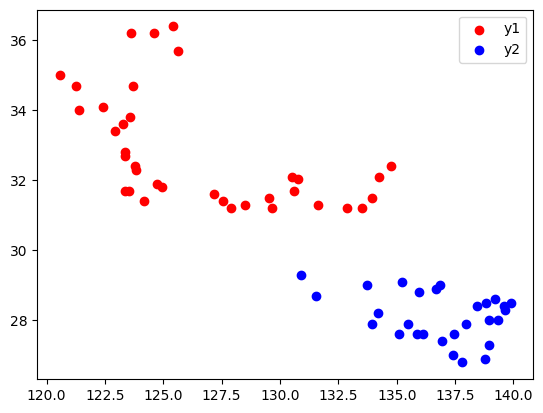

In [36]:
mask = df_month["label_month"]==1
plt.scatter(x=df_month["generation"][mask],y=df_month["temperature"][mask],color = "red",label="y1")
plt.scatter(x=df_month["generation"][~mask],y=df_month["temperature"][~mask],color= "blue",label="y2")
plt.legend()